# A random variable from real data: how many relatives aboard?

*Part 1 · Lesson 7 · another dataset  ·  data: Titanic*

*↩ A companion to [Lesson 7: Random variables, expectation & variance](07-random-variables.ipynb).*

**↩ Back:** [Lesson 7: Random variables, expectation & variance](07-random-variables.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Also:** [The code behind it →](07-random-variables~the-code.ipynb)

The core lesson met a *fair die* — a random variable so tidy it's almost a fantasy: six equally likely
faces, a perfectly flat bar chart, an expected value of exactly 3.5 sitting dead-center. Real data is
almost never that polite. So let's take the **same machinery** — a random variable, its probability
distribution, the expected value $E[X]$, the variance, and the law of large numbers — and turn it loose
on something genuinely lopsided: the **number of family members each Titanic passenger travelled with**.

It's a wonderfully messy random variable. Most people travelled alone; a few travelled in large family
groups. The distribution has a giant spike at one end and a long, thin tail at the other. And yet — this
is the lesson — the **exact same formulas** still work. Run each grey cell with **Shift+Enter**, then tinker.

> **New to notebooks?** The grey boxes below are **code**. Click one and press **Shift + Enter** to run it — the result (a number, a table, or a chart) appears right underneath. Run them **top to bottom**. You do **not** need to understand the first *"Setup"* cell — it just loads the tools and the data, so run it and move on. And you **can't break anything**: re-running a cell is always safe. *(Brand new to all this? The five-minute [Lesson 0 — How these notebooks work](00-how-these-notebooks-work.ipynb) shows you the basics first.)*

In [1]:
# --- Setup: load our helpers and the data --------------------------------
import sys, pathlib
for _p in [pathlib.Path.cwd(), pathlib.Path.cwd().parent]:
    if (_p / 'lib' / 'statslab.py').exists():
        sys.path.insert(0, str(_p / 'lib')); break
import statslab as sl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
sl.use_course_style()
rng = np.random.default_rng(7)   # fixed seed -> reproducible; learner can change it

tit = sl.load_csv('titanic.csv',
                  url='https://web.stanford.edu/class/archive/cs/cs109/cs109.1166/stuff/titanic.csv')
print(f"Loaded {len(tit)} Titanic passengers.")
print("Columns:", list(tit.columns))

Loaded 887 Titanic passengers.
Columns: ['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'Siblings/Spouses Aboard', 'Parents/Children Aboard', 'Fare']


## 1) Defining the random variable

Recall the recipe from the core lesson: a **random variable** (RV) is a rule that turns the outcome of a
chancy experiment into a **number**, and we write it with a capital letter, usually $X$. The "chancy
experiment" here is *pick a Titanic passenger at random*. The number we attach to that passenger is:

$$X = \text{the number of family members that passenger travelled with}.$$

The dataset splits family two ways, so we just add the columns together:

- **Siblings/Spouses Aboard** — brothers, sisters, husbands, wives,
- **Parents/Children Aboard** — mothers, fathers, sons, daughters.

Their sum is the total number of *relatives* aboard with that passenger. $X$ is a **count**, so its
possible values are whole numbers: $0, 1, 2, \ldots$ — someone travelling alone scores a 0.

In [2]:
relatives = tit['Siblings/Spouses Aboard'] + tit['Parents/Children Aboard']
n = len(relatives)

print(f"X = number of relatives aboard, for each of {n} passengers.")
print(f"smallest value of X = {relatives.min()}   (travelling alone)")
print(f"largest  value of X = {relatives.max()}   (a big family group)")
print(f"\nFirst ten passengers' values of X: {relatives.head(10).to_numpy()}")

X = number of relatives aboard, for each of 887 passengers.
smallest value of X = 0   (travelling alone)
largest  value of X = 10   (a big family group)

First ten passengers' values of X: [1 1 0 1 0 0 0 4 2 1]


## 2) The probability distribution — a PMF you have to *estimate*

For the fair die we *knew* the probabilities in advance ($\tfrac{1}{6}$ each). Here we don't know them —
we have to **estimate** each one from the data. The probability that a random passenger travelled with
exactly $k$ relatives is just the **fraction of passengers** who did:

$$P(X = k) = \frac{\text{number of passengers with exactly } k \text{ relatives}}{n}.$$

This list of "every value and its probability" is the **probability mass function**, or **PMF** (the
"mass" is the chunk of probability sitting on each value). Built this way from data it's called an
**empirical** PMF — *empirical* just means "measured from observation" rather than known by theory.

- **The math:** a function $P(k)$ with every $P(k) \ge 0$ and $\sum_k P(k) = 1$.
- **The meaning:** the complete menu of how many relatives a passenger might have, and how common each is.
- **The interpretation:** it describes the *whole shipload* at once, not any single passenger.

In [3]:
counts = relatives.value_counts().sort_index()   # how many passengers at each k
k_vals = counts.index.to_numpy(dtype=int)         # the values 0,1,2,...,10
P = counts.to_numpy() / n                          # P(X = k), the empirical PMF

pmf = pd.DataFrame({'k (relatives)': k_vals, 'passengers': counts.to_numpy(),
                    'P(X=k)': P})
print(pmf.to_string(index=False, float_format=lambda v: f'{v:.3f}'))
print(f"\nProbabilities sum to {P.sum():.4f}  (must be 1).")
print(f"P(X = 0) = {P[k_vals == 0][0]:.3f}  ->  {P[k_vals == 0][0]*100:.1f}% of passengers travelled ALONE.")

 k (relatives)  passengers  P(X=k)
             0         533   0.601
             1         161   0.182
             2         102   0.115
             3          29   0.033
             4          15   0.017
             5          22   0.025
             6          12   0.014
             7           6   0.007
            10           7   0.008

Probabilities sum to 1.0000  (must be 1).
P(X = 0) = 0.601  ->  60.1% of passengers travelled ALONE.


Look at that table and you'll already feel the contrast with the die. The die's PMF was flat — six bars
all the same height. This one is wildly **right-skewed**: a towering spike at $k = 0$ (about 60% of
passengers travelled with no relatives at all), then the bars collapse, leaving a long thin tail that
stretches all the way out to $k = 10$. Let's draw it.

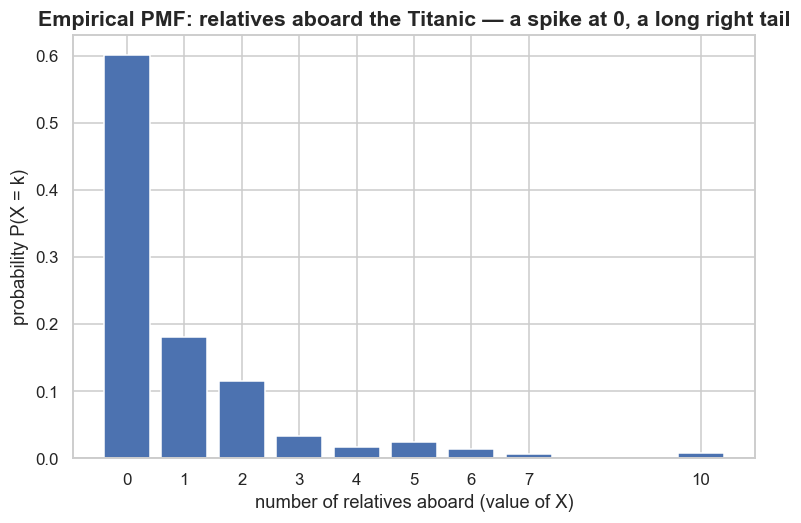

In [4]:
fig, ax = plt.subplots()
ax.bar(k_vals, P, color='#4c72b0', edgecolor='white')
ax.set_xlabel('number of relatives aboard (value of X)')
ax.set_ylabel('probability P(X = k)')
ax.set_title('Empirical PMF: relatives aboard the Titanic — a spike at 0, a long right tail')
ax.set_xticks(k_vals)
plt.show()

Compare this in your mind's eye to the die's six equal bars from the core lesson. Same *kind* of object —
a PMF, bars that sum to 1 — but a completely different *shape*. The die is **symmetric and uniform**;
this is **lopsided and lumpy**. The whole point of what follows is that the formulas for $E[X]$ and
$\operatorname{Var}[X]$ never asked the distribution to be tidy. They work here, unchanged.

## 3) Expected value E[X] — two ways, one answer

The **expected value** is the probability-weighted average of all the values, exactly as before:

$$E[X] = \sum_k k \, P(k).$$

- **The math:** multiply each value $k$ by its probability $P(k)$, and add them all up.
- **The meaning:** the *balance point* of the PMF — where that lopsided bar chart would tip if it were a
  seesaw. It is the long-run average number of relatives, over the whole shipload.
- **The interpretation:** $E[X]$ need **not** be a value $X$ can ever take. We'll find $E[X] \approx 0.91$
  relatives — and *no passenger travelled with 0.91 relatives*. You bring 0 relatives, or 1, or 2; never
  nine-tenths of one. (This is the die's "you can't roll a 3.5" point — and it lands even harder here.)

There are two ways to compute it, and they **must** agree: the weighted-sum formula above, and the plain
average of the raw column. They agree because the weighted sum *is* the average, just bookkept by value.

In [5]:
E = np.sum(k_vals * P)            # way 1: sum of k * P(k), over the PMF
E_mean = relatives.mean()          # way 2: the plain mean of the raw column

print(f"E[X] from the PMF  (sum of k * P(k)) = {E:.4f}")
print(f"E[X] as plain mean (relatives.mean) = {E_mean:.4f}")
print(f"Difference between the two ways      = {abs(E - E_mean):.2e}   (zero, up to rounding)")
print(f"\nA typical passenger travelled with about {E:.2f} relatives on average ...")
print(f"... yet NO passenger can travel with {E:.2f} relatives. E[X] is a long-run average,")
print(f"not a possible outcome — the same lesson as the die's E[X] = 3.5.")

E[X] from the PMF  (sum of k * P(k)) = 0.9087
E[X] as plain mean (relatives.mean) = 0.9087
Difference between the two ways      = 0.00e+00   (zero, up to rounding)

A typical passenger travelled with about 0.91 relatives on average ...
... yet NO passenger can travel with 0.91 relatives. E[X] is a long-run average,
not a possible outcome — the same lesson as the die's E[X] = 3.5.


## 4) Variance and standard deviation — how spread out is it?

The **variance** measures how far, on average, the values land from the expected value — using *squared*
distances so overshoots and undershoots don't cancel:

$$\operatorname{Var}[X] = \sum_k (k - \mu)^2 \, P(k), \qquad \mu = E[X].$$

The **standard deviation** is its square root, $\operatorname{SD}[X] = \sqrt{\operatorname{Var}[X]}$,
which puts us back in the original units (here, "relatives").

- **The math:** weight each squared distance from the mean by its probability, and add.
- **The meaning:** variance is the typical *squared* miss; SD is the everyday "give or take."
- **The interpretation:** a big SD relative to the mean signals a *scattered* variable. Here the SD will
  come out **larger than the mean itself** — a tell-tale fingerprint of that long right tail dragging the
  spread out.

A satisfying check: the variance computed from the PMF is the **population** variance — the same number
as `relatives.var(ddof=0)` (dividing by $n$, not $n-1$).

In [6]:
Var = np.sum((k_vals - E)**2 * P)        # sum of (k - mu)^2 * P(k)
SD  = np.sqrt(Var)

print(f"Var[X] from the PMF             = {Var:.4f}")
print(f"relatives.var(ddof=0) (population) = {relatives.var(ddof=0):.4f}   <- should match Var[X]")
print(f"relatives.var(ddof=1) (sample)     = {relatives.var(ddof=1):.4f}   <- a hair larger")
print()
print(f"SD[X] = {SD:.4f} relatives")
print(f"E[X]  = {E:.4f} relatives")
print(f"\nThe SD ({SD:.2f}) is BIGGER than the mean ({E:.2f}) — the right tail makes X very scattered.")

Var[X] from the PMF             = 2.6083
relatives.var(ddof=0) (population) = 2.6083   <- should match Var[X]
relatives.var(ddof=1) (sample)     = 2.6113   <- a hair larger

SD[X] = 1.6150 relatives
E[X]  = 0.9087 relatives

The SD (1.62) is BIGGER than the mean (0.91) — the right tail makes X very scattered.


*(Optional fine print — safe to skip on a first read.)* The variance from the PMF is the **population**
form (divides by $n$, i.e. `ddof=0`); the **sample** form (`ddof=1`, dividing by $n-1$) sits a hair
above it. We explore *why* the sample version inflates the estimate in a later lesson.

**Interpretation:** a randomly chosen Titanic passenger travelled with about **0.9 relatives** on
average, give or take roughly **1.6** ($\text{SD} \approx 1.6$). But notice how poorly that symmetric
"give or take" describes a one-sided shape: you can't go below 0, yet the SD reaches 1.6 *above and
below* the mean. With a spike-and-tail distribution like this, the SD is an honest number but a crude
summary — exactly the caution the core lesson raised about the skewed prenatal-visits data, only sharper
here because the skew is so extreme.

## 5) The law of large numbers — watch the average converge

We *defined* $E[X]$ as the long-run average. The **law of large numbers** makes that precise: as we draw
more and more passengers at random, the **running sample mean** (the average of everyone drawn so far)
settles down toward the true expected value $E[X]$.

We draw passengers **with replacement** — meaning the same passenger can be picked more than once, like
rolling the same die again — so the pool never runs dry. Early on the running average lurches around
(one large family group can yank it upward); as draws pile up it homes in on the black line at
$E[X] \approx 0.91$. With the die the target was a value you could *almost* land near; here the target is
a number *no single draw can ever equal* — so this is the law of large numbers laid bare: the convergence
is purely a property of the **average**, not of any outcome.

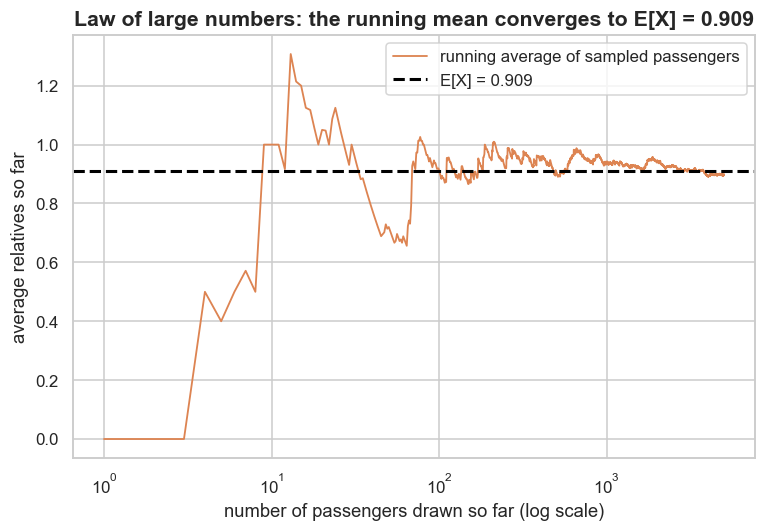

Average of first 10 draws:   1.000
Average of all 5000 draws: 0.899   (target E[X] = 0.909)


In [7]:
n_draws = 5000                                    # <- tinker: try 200, then 50000
draws = rng.choice(relatives.to_numpy(), size=n_draws, replace=True)
running = np.cumsum(draws) / np.arange(1, n_draws + 1)

fig, ax = plt.subplots()
ax.plot(np.arange(1, n_draws + 1), running, color='#dd8452', lw=1.2,
        label='running average of sampled passengers')
ax.axhline(E, color='black', lw=2, ls='--', label=f'E[X] = {E:.3f}')
ax.set_xscale('log')                              # log x-axis spreads out the early, jumpy part
ax.set_xlabel('number of passengers drawn so far (log scale)')
ax.set_ylabel('average relatives so far')
ax.set_title('Law of large numbers: the running mean converges to E[X] = 0.909')
ax.legend(); plt.show()

print(f"Average of first 10 draws:   {running[9]:.3f}")
print(f"Average of all {n_draws} draws: {running[-1]:.3f}   (target E[X] = {E:.3f})")

The same simulation lets us check the **variance** empirically too. The variance of the values we
actually drew should land near the exact $\operatorname{Var}[X] \approx 2.61$ we computed from the PMF —
and the more we draw, the closer it gets.

In [8]:
sim_var = draws.var(ddof=0)        # population-style variance of the drawn values
print(f"Simulated variance of {n_draws} draws: {sim_var:.4f}")
print(f"Exact Var[X] from the PMF:           {Var:.4f}")
print(f"They agree to within {abs(sim_var - Var):.4f} — and tighten as n_draws grows.")

Simulated variance of 5000 draws: 2.5932
Exact Var[X] from the PMF:           2.6083
They agree to within 0.0151 — and tighten as n_draws grows.


## 6) Same machinery, different beast — the die vs. the Titanic

It's worth pausing on just how different these two random variables are, even though every formula we
used was identical.

| | Fair die (core lesson) | Relatives aboard (this lesson) |
|---|---|---|
| Shape of the PMF | flat, **symmetric**, uniform | **right-skewed**, a spike at 0 + long tail |
| Each value equally likely? | yes ($\tfrac{1}{6}$ each) | no — 60% sit at $X=0$ alone |
| $E[X]$ | exactly **3.5** | about **0.91** |
| Is $E[X]$ a possible outcome? | no (can't roll 3.5) | no (can't travel with 0.91 relatives) |
| SD vs. mean | SD $\approx 1.71$, *smaller* than mean | SD $\approx 1.61$, *bigger* than mean |
| How we got the PMF | **known** by theory | **estimated** from data |

The takeaway: the definitions of a random variable, its PMF, $E[X] = \sum k\,P(k)$, the variance, and the
law of large numbers are **completely indifferent** to whether the distribution is a textbook's tidy die
or a lopsided slice of real history. You learned the tools on the die because it was clean; they keep
working out here in the wild.

## Now you try

Predict first, then change one thing and re-run:

1. In the **convergence** cell (section 5), set `n_draws = 200`. Run it a few times (change the seed in
   the Setup cell, e.g. `default_rng(1)`, `default_rng(2)`). How far can the final running average stray
   from 0.91 with only 200 draws? Then try `n_draws = 50000` — what does that say about how *fast* the
   law of large numbers tames this skewed variable compared with the symmetric die?

2. **Lump the big families together.** In a new cell, make a capped version
   `capped = relatives.clip(upper=3)` (everyone with 4+ relatives is counted as 3), rebuild its PMF, and
   recompute `E[X]`. Predict *before running*: does chopping off the long tail pull the mean **down**?
   By a lot or a little? Why does the tail matter so much less than the spike at 0?

3. **Define your own random variable.** Let $Y = $ `tit['Fare']` and compute its mean and SD directly
   with `.mean()` and `.std(ddof=0)`. Fare is *continuous*, not a count — does the "$E[X]$ need not be a
   possible value" idea still apply? (Hint: it applies to *any* random variable.)

4. **Check the alone-rate.** Compute `(relatives == 0).mean()`. You've just estimated $P(X = 0)$ a second
   way. Does it match the 0.601 in the PMF table?

## What you learned

- A **random variable** turns a chancy outcome into a number; here $X$ = relatives aboard, built by
  adding two real columns. Its **PMF** lists every value and its probability — **estimated** from data
  ($P(k) = $ count of $k \div n$) because, unlike the die, we don't know it in advance.
- **Expected value** $E[X] = \sum_k k\,P(k)$ is the long-run average / balance point. We computed it two
  ways — the weighted sum and the plain column mean — and they agreed at $E[X] \approx 0.909$.
- $E[X]$ **need not be an outcome you can observe**: no passenger travelled with 0.909 relatives, just as
  no die lands on 3.5. Expected value is an average, not a typical single result.
- **Variance** $\operatorname{Var}[X] = \sum_k (k-\mu)^2 P(k) \approx 2.61$ and its root, the **SD**
  $\approx 1.61$, measure spread; the PMF's variance is the **population** form (`ddof=0`). Here the SD
  is *larger than the mean* — the signature of a long right tail.
- The **law of large numbers** still holds on this lopsided real variable: the running mean of randomly
  drawn passengers converged to $E[X] = 0.909$, the very number we computed from the PMF.
- Above all: the **same machinery** that described a flat, symmetric die describes this spiky,
  right-skewed real-world count without changing a single formula.

---

**↩ Back to the lesson:** [Lesson 7: Random variables, expectation & variance](07-random-variables.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Also:** [The code behind it](07-random-variables~the-code.ipynb)